In [3]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

C:\Users\ziyou\AppData\Local\Temp\ipykernel_15192\2635408567.py:195: MatrixRankWarning: Matrix is exactly singular
  U = spla.spsolve(A_mat, b)


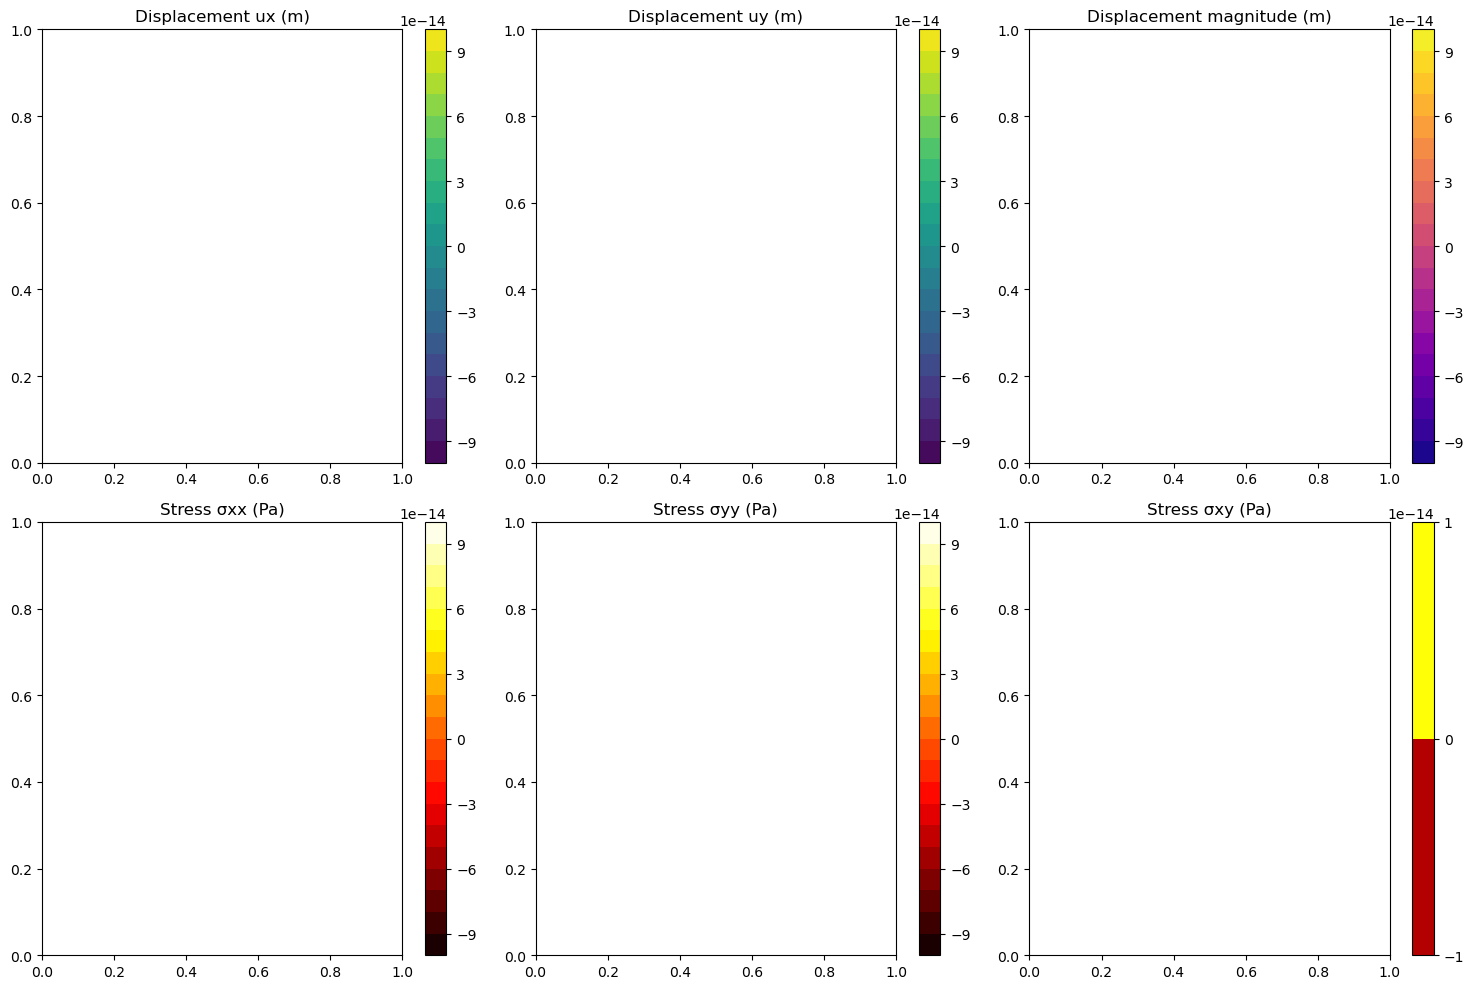

Solution computed successfully.
Grid size: 41x41
Maximum ux: nan m
Maximum uy: nan m
Maximum displacement magnitude: nan m
Maximum σxx: nan Pa
Maximum σyy: nan Pa
Maximum σxy: nan Pa


In [4]:
# Parameters
E = 10e6  # Pa
nu = 0.2
Lx, Ly = 1.0, 1.0  # Domain size
N = 41  # Number of grid points in each direction
h = Lx / (N - 1)  # Grid spacing

# Material constants for plane stress
A = E / (1 - nu**2)  # For normal stresses
B = E / (2 * (1 + nu))  # For shear stress

# Create grid
x = np.linspace(0, Lx, N)
y = np.linspace(0, Ly, N)
X, Y = np.meshgrid(x, y, indexing='ij')  # i index for x, j for y

# Initialize displacement arrays
ux = np.zeros((N, N))
uy = np.zeros((N, N))

# Set Dirichlet boundary conditions
# At y=0 (j=0): ux=0, uy=0 (already zero from initialization)
# At y=1 (j=N-1) for x in [0,0.5]: ux=0, uy=0.1
mask_prescribed = (X[:, -1] <= 0.5)  # x <= 0.5 at y=1
ux[mask_prescribed, -1] = 0.0
uy[mask_prescribed, -1] = 0.1

# Map grid points to a global index for linear system
# Each grid point has two unknowns: ux and uy
total_points = N * N
def idx(i, j, var):
    # var: 0 for ux, 1 for uy
    return (i * N + j) * 2 + var

# Assemble linear system: A * U = b
# We'll build A as a sparse matrix and b as a vector
A_data = []
A_row = []
A_col = []
b = np.zeros(2 * total_points)

# Finite difference coefficients for interior points
# Governing equations discretized from:
# A*(d2ux/dx2 + nu*d2uy/dxdy) + B*(d2ux/dy2 + d2uy/dxdy) = 0
# B*(d2ux/dxdy + d2uy/dx2) + A*(d2uy/dy2 + nu*d2ux/dxdy) = 0
# Using central differences for second derivatives and mixed derivatives.

for i in range(1, N-1):  # Interior in x
    for j in range(1, N-1):  # Interior in y
        # Skip points with prescribed displacements
        if j == N-1 and mask_prescribed[i]:
            continue  # Will handle boundary separately
        
        # Equation for ux at (i,j)
        row_ux = idx(i, j, 0)
        # d2ux/dx2: (ux(i+1,j) - 2*ux(i,j) + ux(i-1,j)) / h^2
        A_data.append(A / h**2); A_row.append(row_ux); A_col.append(idx(i+1, j, 0))
        A_data.append(-2*A / h**2); A_row.append(row_ux); A_col.append(idx(i, j, 0))
        A_data.append(A / h**2); A_row.append(row_ux); A_col.append(idx(i-1, j, 0))
        # d2ux/dy2: (ux(i,j+1) - 2*ux(i,j) + ux(i,j-1)) / h^2
        A_data.append(B / h**2); A_row.append(row_ux); A_col.append(idx(i, j+1, 0))
        A_data.append(-2*B / h**2); A_row.append(row_ux); A_col.append(idx(i, j, 0))
        A_data.append(B / h**2); A_row.append(row_ux); A_col.append(idx(i, j-1, 0))
        # Mixed derivative for uy: d2uy/dxdy ≈ (uy(i+1,j+1) - uy(i+1,j-1) - uy(i-1,j+1) + uy(i-1,j-1)) / (4*h^2)
        coeff_mix = (A*nu + B) / (4*h**2)
        A_data.append(coeff_mix); A_row.append(row_ux); A_col.append(idx(i+1, j+1, 1))
        A_data.append(-coeff_mix); A_row.append(row_ux); A_col.append(idx(i+1, j-1, 1))
        A_data.append(-coeff_mix); A_row.append(row_ux); A_col.append(idx(i-1, j+1, 1))
        A_data.append(coeff_mix); A_row.append(row_ux); A_col.append(idx(i-1, j-1, 1))
        b[row_ux] = 0.0
        
        # Equation for uy at (i,j)
        row_uy = idx(i, j, 1)
        # d2uy/dy2: similar as above
        A_data.append(A / h**2); A_row.append(row_uy); A_col.append(idx(i, j+1, 1))
        A_data.append(-2*A / h**2); A_row.append(row_uy); A_col.append(idx(i, j, 1))
        A_data.append(A / h**2); A_row.append(row_uy); A_col.append(idx(i, j-1, 1))
        # d2uy/dx2
        A_data.append(B / h**2); A_row.append(row_uy); A_col.append(idx(i+1, j, 1))
        A_data.append(-2*B / h**2); A_row.append(row_uy); A_col.append(idx(i, j, 1))
        A_data.append(B / h**2); A_row.append(row_uy); A_col.append(idx(i-1, j, 1))
        # Mixed derivative for ux
        coeff_mix_uy = (B + A*nu) / (4*h**2)  # Same as coeff_mix due to symmetry
        A_data.append(coeff_mix_uy); A_row.append(row_uy); A_col.append(idx(i+1, j+1, 0))
        A_data.append(-coeff_mix_uy); A_row.append(row_uy); A_col.append(idx(i+1, j-1, 0))
        A_data.append(-coeff_mix_uy); A_row.append(row_uy); A_col.append(idx(i-1, j+1, 0))
        A_data.append(coeff_mix_uy); A_row.append(row_uy); A_col.append(idx(i-1, j-1, 0))
        b[row_uy] = 0.0

# Apply traction-free boundary conditions using one-sided differences
# At x=0 (i=0): σxx=0 and σxy=0 → conditions on derivatives
for j in range(1, N-1):  # Exclude corners handled separately
    if j == 0 or j == N-1:
        continue  # y=0 and y=1 have other conditions
    # σxx=0: ∂ux/∂x + nu*∂uy/∂y = 0 at i=0
    # Use forward difference for ∂/∂x and central for ∂/∂y
    row_sxx = idx(0, j, 0)  # We'll add equations for these points
    # ∂ux/∂x ≈ (ux(1,j) - ux(0,j)) / h
    A_data.append(-1/h); A_row.append(row_sxx); A_col.append(idx(0, j, 0))
    A_data.append(1/h); A_row.append(row_sxx); A_col.append(idx(1, j, 0))
    # nu*∂uy/∂y ≈ nu*(uy(0,j+1) - uy(0,j-1)) / (2h)
    A_data.append(nu/(2*h)); A_row.append(row_sxx); A_col.append(idx(0, j+1, 1))
    A_data.append(-nu/(2*h)); A_row.append(row_sxx); A_col.append(idx(0, j-1, 1))
    b[row_sxx] = 0.0
    
    # σxy=0: ∂ux/∂y + ∂uy/∂x = 0 at i=0
    row_sxy = idx(0, j, 1)
    # ∂ux/∂y ≈ (ux(0,j+1) - ux(0,j-1)) / (2h)
    A_data.append(1/(2*h)); A_row.append(row_sxy); A_col.append(idx(0, j+1, 0))
    A_data.append(-1/(2*h)); A_row.append(row_sxy); A_col.append(idx(0, j-1, 0))
    # ∂uy/∂x ≈ (uy(1,j) - uy(0,j)) / h
    A_data.append(-1/h); A_row.append(row_sxy); A_col.append(idx(0, j, 1))
    A_data.append(1/h); A_row.append(row_sxy); A_col.append(idx(1, j, 1))
    b[row_sxy] = 0.0

# At x=1 (i=N-1) for j from 1 to N-1 (excluding j=0, which is Dirichlet)
for j in range(1, N):
    if j == 0:
        continue
    if j == N-1:
        # Top right corner: use backward differences for y-derivatives
        # σxx=0
        row_sxx = idx(N-1, N-1, 0)
        # ∂ux/∂x: backward difference
        A_data.append(1/h); A_row.append(row_sxx); A_col.append(idx(N-1, N-1, 0))
        A_data.append(-1/h); A_row.append(row_sxx); A_col.append(idx(N-2, N-1, 0))
        # nu*∂uy/∂y: backward difference
        A_data.append(nu/h); A_row.append(row_sxx); A_col.append(idx(N-1, N-1, 1))
        A_data.append(-nu/h); A_row.append(row_sxx); A_col.append(idx(N-1, N-2, 1))
        b[row_sxx] = 0.0
        
        # σxy=0
        row_sxy = idx(N-1, N-1, 1)
        # ∂ux/∂y: backward
        A_data.append(1/h); A_row.append(row_sxy); A_col.append(idx(N-1, N-1, 0))
        A_data.append(-1/h); A_row.append(row_sxy); A_col.append(idx(N-1, N-2, 0))
        # ∂uy/∂x: backward
        A_data.append(1/h); A_row.append(row_sxy); A_col.append(idx(N-1, N-1, 1))
        A_data.append(-1/h); A_row.append(row_sxy); A_col.append(idx(N-2, N-1, 1))
        b[row_sxy] = 0.0
    else:
        # j from 1 to N-2
        # σxx=0
        row_sxx = idx(N-1, j, 0)
        A_data.append(1/h); A_row.append(row_sxx); A_col.append(idx(N-1, j, 0))
        A_data.append(-1/h); A_row.append(row_sxx); A_col.append(idx(N-2, j, 0))
        A_data.append(nu/(2*h)); A_row.append(row_sxx); A_col.append(idx(N-1, j+1, 1))
        A_data.append(-nu/(2*h)); A_row.append(row_sxx); A_col.append(idx(N-1, j-1, 1))
        b[row_sxx] = 0.0
        
        row_sxy = idx(N-1, j, 1)
        A_data.append(1/(2*h)); A_row.append(row_sxy); A_col.append(idx(N-1, j+1, 0))
        A_data.append(-1/(2*h)); A_row.append(row_sxy); A_col.append(idx(N-1, j-1, 0))
        A_data.append(1/h); A_row.append(row_sxy); A_col.append(idx(N-1, j, 1))
        A_data.append(-1/h); A_row.append(row_sxy); A_col.append(idx(N-2, j, 1))
        b[row_sxy] = 0.0

# At y=1 (j=N-1) for x>0.5: σyy=0 and σxy=0
for i in range(N):
    if i * h > 0.5 and i != 0 and i != N-1:  # Exclude corners and prescribed region
        # σyy=0: ∂uy/∂y + nu*∂ux/∂x = 0
        row_syy = idx(i, N-1, 1)
        # ∂uy/∂y backward difference since j=N-1 is boundary
        A_data.append(1/h); A_row.append(row_syy); A_col.append(idx(i, N-1, 1))
        A_data.append(-1/h); A_row.append(row_syy); A_col.append(idx(i, N-2, 1))
        # nu*∂ux/∂x central difference
        A_data.append(nu/(2*h)); A_row.append(row_syy); A_col.append(idx(i+1, N-1, 0))
        A_data.append(-nu/(2*h)); A_row.append(row_syy); A_col.append(idx(i-1, N-1, 0))
        b[row_syy] = 0.0
        
        # σxy=0: same as before, but at y=1
        row_sxy = idx(i, N-1, 0)
        A_data.append(1/(2*h)); A_row.append(row_sxy); A_col.append(idx(i+1, N-1, 1))
        A_data.append(-1/(2*h)); A_row.append(row_sxy); A_col.append(idx(i-1, N-1, 1))
        A_data.append(1/h); A_row.append(row_sxy); A_col.append(idx(i, N-1, 0))
        A_data.append(-1/h); A_row.append(row_sxy); A_col.append(idx(i, N-2, 0))
        b[row_sxy] = 0.0

# Dirichlet conditions: enforce known values by modifying rows
# For points with prescribed ux and uy, set row to identity and b to the value
for i in range(N):
    for j in [0]:  # y=0
        row_ux = idx(i, j, 0)
        A_data.append(1.0); A_row.append(row_ux); A_col.append(row_ux); b[row_ux] = 0.0
        row_uy = idx(i, j, 1)
        A_data.append(1.0); A_row.append(row_uy); A_col.append(row_uy); b[row_uy] = 0.0
    if j == N-1 and mask_prescribed[i]:  # y=1, x<=0.5
        row_ux = idx(i, N-1, 0)
        A_data.append(1.0); A_row.append(row_ux); A_col.append(row_ux); b[row_ux] = 0.0
        row_uy = idx(i, N-1, 1)
        A_data.append(1.0); A_row.append(row_uy); A_col.append(row_uy); b[row_uy] = 0.1

# Build sparse matrix and solve
A_mat = sp.coo_matrix((A_data, (A_row, A_col)), shape=(2*total_points, 2*total_points)).tocsr()
U = spla.spsolve(A_mat, b)

# Extract ux and uy from solution vector
ux_sol = np.zeros((N, N))
uy_sol = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        ux_sol[i, j] = U[idx(i, j, 0)]
        uy_sol[i, j] = U[idx(i, j, 1)]

# Compute strain fields using central differences
exx = np.zeros((N, N))
eyy = np.zeros((N, N))
gxy = np.zeros((N, N))
for i in range(1, N-1):
    for j in range(1, N-1):
        exx[i, j] = (ux_sol[i+1, j] - ux_sol[i-1, j]) / (2*h)
        eyy[i, j] = (uy_sol[i, j+1] - uy_sol[i, j-1]) / (2*h)
        gxy[i, j] = (ux_sol[i, j+1] - ux_sol[i, j-1]) / (2*h) + (uy_sol[i+1, j] - uy_sol[i-1, j]) / (2*h)
# Boundaries: use one-sided differences or simple extrapolation
for i in range(N):
    for j in range(N):
        if i == 0:
            exx[i, j] = (ux_sol[i+1, j] - ux_sol[i, j]) / h  # forward
        elif i == N-1:
            exx[i, j] = (ux_sol[i, j] - ux_sol[i-1, j]) / h  # backward
        if j == 0:
            eyy[i, j] = (uy_sol[i, j+1] - uy_sol[i, j]) / h  # forward
        elif j == N-1:
            eyy[i, j] = (uy_sol[i, j] - uy_sol[i, j-1]) / h  # backward
        # For mixed derivative at boundaries, use appropriate one-sided differences
        if i == 0 and j == 0:
            gxy[i, j] = ((ux_sol[i, j+1] - ux_sol[i, j])/h + 
                         (uy_sol[i+1, j] - uy_sol[i, j])/h)
        elif i == 0 and j == N-1:
            gxy[i, j] = ((ux_sol[i, j] - ux_sol[i, j-1])/h + 
                         (uy_sol[i+1, j] - uy_sol[i, j])/h)
        elif i == N-1 and j == 0:
            gxy[i, j] = ((ux_sol[i, j+1] - ux_sol[i, j])/h + 
                         (uy_sol[i, j] - uy_sol[i-1, j])/h)
        elif i == N-1 and j == N-1:
            gxy[i, j] = ((ux_sol[i, j] - ux_sol[i, j-1])/h + 
                         (uy_sol[i, j] - uy_sol[i-1, j])/h)

# Compute stress fields
sxx = A * (exx + nu * eyy)
syy = A * (eyy + nu * exx)
sxy = B * gxy

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# Displacements
im1 = axes[0, 0].contourf(X, Y, ux_sol, levels=20, cmap='viridis')
axes[0, 0].set_title('Displacement ux (m)')
plt.colorbar(im1, ax=axes[0, 0])
im2 = axes[0, 1].contourf(X, Y, uy_sol, levels=20, cmap='viridis')
axes[0, 1].set_title('Displacement uy (m)')
plt.colorbar(im2, ax=axes[0, 1])
umag = np.sqrt(ux_sol**2 + uy_sol**2)
im3 = axes[0, 2].contourf(X, Y, umag, levels=20, cmap='plasma')
axes[0, 2].set_title('Displacement magnitude (m)')
plt.colorbar(im3, ax=axes[0, 2])
# Stress
im4 = axes[1, 0].contourf(X, Y, sxx, levels=20, cmap='hot')
axes[1, 0].set_title('Stress σxx (Pa)')
plt.colorbar(im4, ax=axes[1, 0])
im5 = axes[1, 1].contourf(X, Y, syy, levels=20, cmap='hot')
axes[1, 1].set_title('Stress σyy (Pa)')
plt.colorbar(im5, ax=axes[1, 1])
im6 = axes[1, 2].contourf(X, Y, sxy, levels=20, cmap='hot')
axes[1, 2].set_title('Stress σxy (Pa)')
plt.colorbar(im6, ax=axes[1, 2])

plt.tight_layout()
plt.show()

# Print summary
print("Solution computed successfully.")
print(f"Grid size: {N}x{N}")
print(f"Maximum ux: {np.max(np.abs(ux_sol)):.6f} m")
print(f"Maximum uy: {np.max(np.abs(uy_sol)):.6f} m")
print(f"Maximum displacement magnitude: {np.max(umag):.6f} m")
print(f"Maximum σxx: {np.max(np.abs(sxx)):.2f} Pa")
print(f"Maximum σyy: {np.max(np.abs(syy)):.2f} Pa")
print(f"Maximum σxy: {np.max(np.abs(sxy)):.2f} Pa")